# IN5450 Project 3
## Theodor Wålberg
### Setup

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import scipy.signal

# Load data from .mat file
mat_data = scipy.io.loadmat("mimo_project.mat")

# Extract variables
tdma_data = mat_data["tdma_data"]    # [Nt, Nrx, Ntx]
cdma_data = mat_data["cdma_data"]    # [Nt, Nrx]
rx_pos = mat_data["rx_pos"].flatten()
tx_pos = mat_data["tx_pos"].flatten()
fs = mat_data["fs"].item()

# Constants
c = 340        # Speed of sound [m/s]
B = 10000      # Bandwidth [Hz]
fc = 10000     # Center frequency [Hz]
Tp = 0.01      # Pulse length [s]

# Data verification
Nt, Nrx, Ntx = tdma_data.shape
print(f"tdma_data shape: {tdma_data.shape}  (Nt={Nt}, Nrx={Nrx}, Ntx={Ntx})")
print(f"cdma_data shape: {cdma_data.shape}")
print(f"Sampling frequency: fs = {fs} Hz")
print(f"Number of receivers: Nrx = {Nrx}")
print(f"Number of transmitters: Ntx = {Ntx}")

tdma_data shape: (10000, 32, 2)  (Nt=10000, Nrx=32, Ntx=2)
cdma_data shape: (10000, 32)
Sampling frequency: fs = 200000 Hz
Number of receivers: Nrx = 32
Number of transmitters: Ntx = 2


### Part 1: Pulse compression

tdma_compressed shape: (10000, 32, 2)


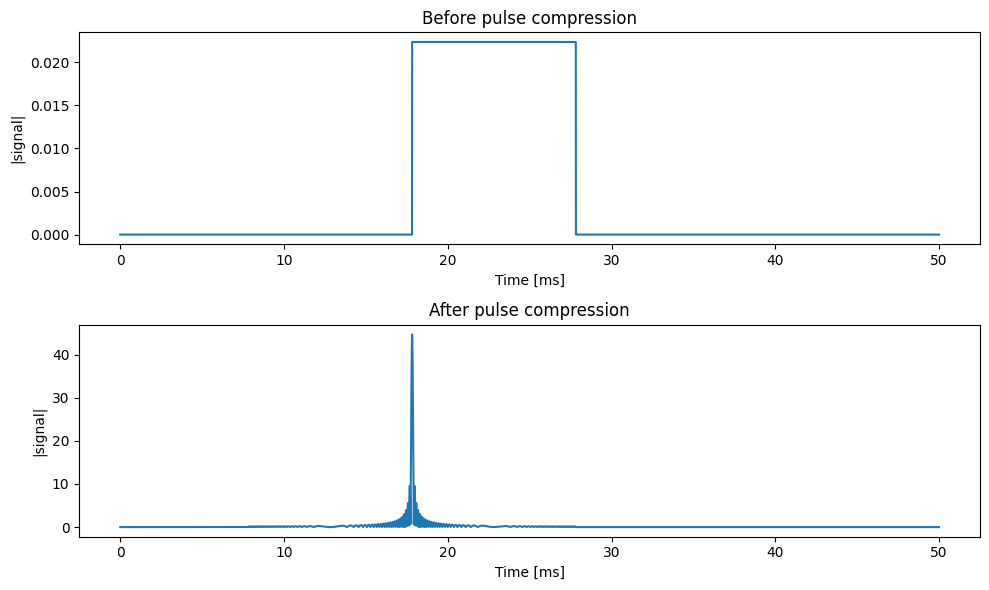

In [38]:
# --- Define waveform replicas ---
alpha = B / Tp  # Chirp rate
t_p = np.arange(0, Tp, 1 / fs)  # Time vector for pulse

# LFM upchirp and downchirp replicas
s_tx_up = np.exp(1j * 2 * np.pi * ((fc - B / 2) * t_p + alpha * t_p**2 / 2))
s_tx_down = np.exp(1j * 2 * np.pi * ((fc + B / 2) * t_p - alpha * t_p**2 / 2))


# --- Pulse compression function ---
def pulse_compression(data, replica):
    """Cross-correlate data with replica, keeping only positive lags."""
    corr = scipy.signal.correlate(data, replica, mode="full")
    # Keep only the second half (positive lags, length = len(data))
    return corr[len(replica) - 1 :]


# --- Process TDMA data (upchirp used for both transmits) ---
tdma_compressed = np.zeros_like(tdma_data[: len(pulse_compression(tdma_data[:, 0, 0], s_tx_up)), :, :])
tdma_compressed = np.stack(
    [
        np.stack(
            [pulse_compression(tdma_data[:, rx, tx], s_tx_up) for rx in range(Nrx)],
            axis=1,
        )
        for tx in range(Ntx)
    ],
    axis=2,
)
print(f"tdma_compressed shape: {tdma_compressed.shape}")


# --- Visualize before/after pulse compression ---
rx_idx = 0  # Channel 0
tx_idx = 0
t_axis = np.arange(tdma_data.shape[0]) / fs

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(t_axis * 1e3, np.abs(tdma_data[:, rx_idx, tx_idx]))
axes[0].set_title("Before pulse compression")
axes[0].set_xlabel("Time [ms]")
axes[0].set_ylabel("|signal|")

t_axis_comp = np.arange(tdma_compressed.shape[0]) / fs
axes[1].plot(t_axis_comp * 1e3, np.abs(tdma_compressed[:, rx_idx, tx_idx]))
axes[1].set_title("After pulse compression")
axes[1].set_xlabel("Time [ms]")
axes[1].set_ylabel("|signal|")

plt.tight_layout()
plt.show()

The difference is quite obvious. The pulse compressed signal is much narrower than the original. This increases the time resolution, while allowing the signal to be wide with a lot of energy to travel far.

Investigate the pulse compressed timeseries, and estimate the practical time-resolution by calculating the Full Width Half Maximum (FWHM) on the magnitude squared signal on one timeseries. Compare with the theoretical.

=== Time Resolution Comparison ===
Theoretical:  δτ = 1/B = 100.00 µs
Practical FWHM (-3 dB):    88.60 µs
Ratio (practical/theoretical): 0.886


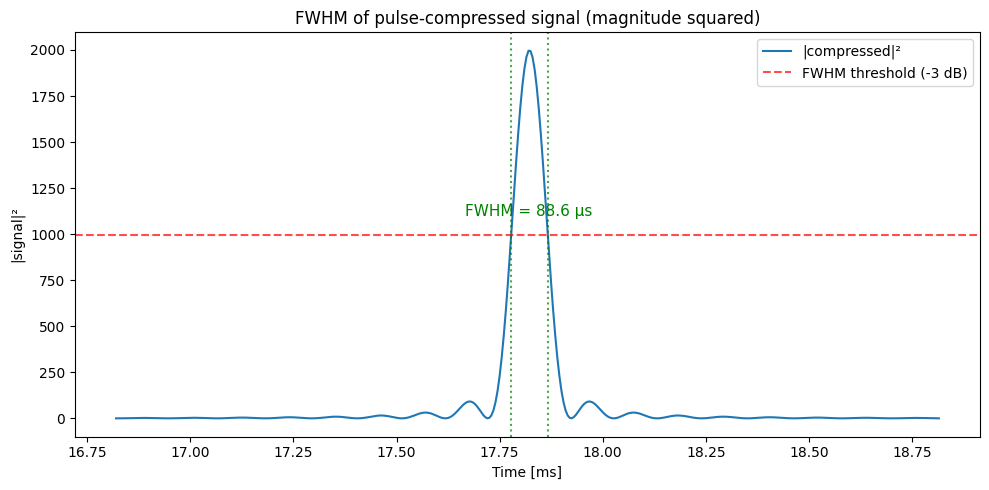


The practical FWHM (88.60 µs) is close to the theoretical δτ = 1/B = 100.00 µs.
This confirms that pulse compression achieves near-theoretical time resolution.


In [39]:
# --- FWHM analysis on magnitude-squared signal ---
rx_ch = 0
tx_ch = 0
sig_power = np.abs(tdma_compressed[:, rx_ch, tx_ch]) ** 2
t_comp = np.arange(len(sig_power)) / fs

# Find peak
peak_idx = np.argmax(sig_power)
peak_val = sig_power[peak_idx]
half_max = peak_val / 2  # FWHM threshold (-3 dB on power)

# Find left and right crossings via interpolation for better accuracy
left = peak_idx
while left > 0 and sig_power[left] >= half_max:
    left -= 1
# Linear interpolation for left crossing
t_left = t_comp[left] + (half_max - sig_power[left]) / (sig_power[left + 1] - sig_power[left]) * (t_comp[left + 1] - t_comp[left])

right = peak_idx
while right < len(sig_power) - 1 and sig_power[right] >= half_max:
    right += 1
# Linear interpolation for right crossing
t_right = t_comp[right - 1] + (half_max - sig_power[right - 1]) / (sig_power[right] - sig_power[right - 1]) * (t_comp[right] - t_comp[right - 1])

fwhm_practical = t_right - t_left
delta_tau_theoretical = 1 / B

print("=== Time Resolution Comparison ===")
print(f"Theoretical:  δτ = 1/B = {delta_tau_theoretical*1e6:.2f} µs")
print(f"Practical FWHM (-3 dB):    {fwhm_practical*1e6:.2f} µs")
print(f"Ratio (practical/theoretical): {fwhm_practical / delta_tau_theoretical:.3f}")

# --- Zoomed plot around the peak with FWHM annotation ---
window = int(0.001 * fs)  # 1 ms window around peak
i_start = max(0, peak_idx - window)
i_end = min(len(sig_power), peak_idx + window)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_comp[i_start:i_end] * 1e3, sig_power[i_start:i_end], label="|compressed|²")
ax.axhline(half_max, color="r", linestyle="--", alpha=0.7, label=f"FWHM threshold (-3 dB)")
ax.axvline(t_left * 1e3, color="g", linestyle=":", alpha=0.7)
ax.axvline(t_right * 1e3, color="g", linestyle=":", alpha=0.7)
ax.text(t_comp[peak_idx] * 1e3, half_max * 1.1, f"FWHM = {fwhm_practical*1e6:.1f} µs",
        ha="center", fontsize=11, color="green")
ax.set_xlabel("Time [ms]")
ax.set_ylabel("|signal|²")
ax.set_title("FWHM of pulse-compressed signal (magnitude squared)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nThe practical FWHM ({fwhm_practical*1e6:.2f} µs) is close to the theoretical δτ = 1/B = {delta_tau_theoretical*1e6:.2f} µs.")
print(f"This confirms that pulse compression achieves near-theoretical time resolution.")

### Part 2: Virtual Array

1-Tx virtual array: 32 elements, span = 0.5270 m
2-Tx virtual array: 64 elements, span = 0.5355 m


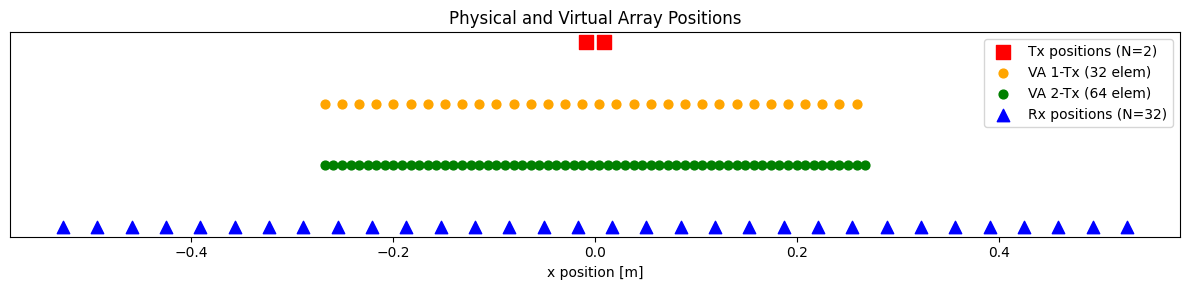


=== Resolution Analysis (2-Tx Virtual Array) ===
Wavelength:             λ = c/fc = 3.40 cm
Virtual aperture length: L_va = 0.5355 m
Lateral resolution:     δθ = λ/L_va = 0.0635 rad (3.64°)
Lateral resolution at R=4.0 m: δx = R·δθ = 25.40 cm
Axial resolution:       δy = c/(2B) = 1.70 cm


In [40]:
# --- Construct virtual arrays ---
# Virtual element position: x_va = (x_tx + x_rx) / 2

# 1-Tx case: only the first transmitter
va_1tx = (tx_pos[0] + rx_pos) / 2

# 2-Tx case: all transmitters (Ntx x Nrx virtual elements)
va_2tx = np.array([(tx + rx_pos) / 2 for tx in tx_pos]).flatten()
va_2tx = np.sort(va_2tx)

# With 1 Tx we get Nrx virtual elements; with 2 Tx we get Ntx*Nrx virtual elements.
# The two transmitters placed at the array ends effectively double the aperture,
# filling in positions between and beyond the 1-Tx virtual array, thus increasing
# the effective aperture length L_va and improving lateral resolution.

print(f"1-Tx virtual array: {len(va_1tx)} elements, span = {va_1tx.ptp():.4f} m")
print(f"2-Tx virtual array: {len(va_2tx)} elements, span = {va_2tx.ptp():.4f} m")


# --- Visualization ---
fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(tx_pos, np.ones(len(tx_pos)) * 0.6, marker="s", s=100, color="red", label=f"Tx positions (N={Ntx})", zorder=3)
ax.scatter(va_1tx, np.ones(len(va_1tx)) * 0.3, marker="o", s=40, color="orange", label=f"VA 1-Tx ({len(va_1tx)} elem)", zorder=3)
ax.scatter(va_2tx, np.zeros(len(va_2tx)), marker="o", s=40, color="green", label=f"VA 2-Tx ({len(va_2tx)} elem)", zorder=3)
ax.scatter(rx_pos, -np.ones_like(rx_pos) * 0.3, marker="^", s=80, color="blue", label=f"Rx positions (N={Nrx})", zorder=3)
ax.set_xlabel("x position [m]")
ax.set_yticks([])
ax.set_title("Physical and Virtual Array Positions")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


# --- Calculate resolutions ---
lam = c / fc  # Wavelength
L_va = va_2tx.ptp()  # Total length of 2-Tx virtual array

# Lateral resolution (angular)
delta_theta = lam / L_va  # [rad]

# Lateral resolution at range R
R = 4.0  # [m]
delta_x = R * delta_theta  # [m]

# Axial (range) resolution: pulse-echo => c / (2B)
delta_y = c / (2 * B)  # [m]

print(f"\n=== Resolution Analysis (2-Tx Virtual Array) ===")
print(f"Wavelength:             λ = c/fc = {lam*100:.2f} cm")
print(f"Virtual aperture length: L_va = {L_va:.4f} m")
print(f"Lateral resolution:     δθ = λ/L_va = {delta_theta:.4f} rad ({np.degrees(delta_theta):.2f}°)")
print(f"Lateral resolution at R={R} m: δx = R·δθ = {delta_x*100:.2f} cm")
print(f"Axial resolution:       δy = c/(2B) = {delta_y*100:.2f} cm")

### Part 3: Delay-And-Sum

In [41]:
# --- Define imaging grid ---
dx = 0.01  # Grid resolution [m]
dy = 0.01
grid_x = np.arange(-5, 5 + dx, dx)
grid_y = np.arange(0, 10 + dy, dy)

print(f"Grid: {len(grid_x)} x {len(grid_y)} = {len(grid_x)*len(grid_y)} pixels")
print(f"X range: [{grid_x[0]}, {grid_x[-1]}] m, Y range: [{grid_y[0]}, {grid_y[-1]}] m")


# --- Vectorized DAS beamforming function ---
def vectorized_das(data, grid_x, grid_y, tx_positions, rx_positions, fs, c):
    """
    Vectorized Delay-and-Sum beamformer for bistatic MIMO pulse-echo imaging.

    Loops only over Tx and Rx; all pixel calculations are done with NumPy broadcasting.

    Parameters:
        data: Pulse-compressed data.
               3D [Nt, Nrx, Ntx] or 2D [Nt, Nrx] (single Tx)
        grid_x, grid_y: 1D arrays for the imaging grid
        tx_positions: transmitter x-positions used
        rx_positions: receiver x-positions
        fs: sampling frequency
        c: speed of sound

    Returns:
        image: 2D complex array [len(grid_y), len(grid_x)]
    """
    # Promote 2D data to 3D
    if data.ndim == 2:
        data = data[:, :, np.newaxis]

    Nt_data, n_rx, n_tx = data.shape
    Ny = len(grid_y)
    Nx = len(grid_x)

    # 2D coordinate grids: shape (Ny, Nx)
    GX, GY = np.meshgrid(grid_x, grid_y)

    # Accumulate the image incrementally to keep memory usage reasonable
    image = np.zeros((Ny, Nx), dtype=complex)

    for itx in range(n_tx):
        # Distance from Tx_itx to every pixel: (Ny, Nx)
        R_tx = np.sqrt((tx_positions[itx] - GX)**2 + GY**2)

        for irx in range(n_rx):
            # Distance from every pixel to Rx_irx: (Ny, Nx)
            R_rx = np.sqrt((rx_positions[irx] - GX)**2 + GY**2)

            # Bistatic travel distance -> sample indices
            R_total = R_tx + R_rx
            idx_map = np.round(R_total / c * fs).astype(int)

            # Mask out-of-bounds indices
            valid = (idx_map >= 0) & (idx_map < Nt_data)

            # Clip to valid range for safe indexing, then zero out invalid pixels
            idx_safe = np.clip(idx_map, 0, Nt_data - 1)

            # Vectorized data extraction: all pixels at once
            pixel_values = data[idx_safe, irx, itx]
            pixel_values[~valid] = 0.0

            image += pixel_values

    return image


def plot_das_image(image, grid_x, grid_y, title="DAS Image", dynamic_range=40):
    """Plot DAS image in dB with specified dynamic range."""
    mag = np.abs(image)
    mag[mag == 0] = np.finfo(float).eps
    img_db = 20 * np.log10(mag / mag.max())

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.pcolormesh(grid_x, grid_y, img_db, shading="auto",
                       cmap="inferno", vmin=-dynamic_range, vmax=0)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, label="dB")
    plt.tight_layout()
    plt.show()

Grid: 1001 x 1001 = 1002001 pixels
X range: [-5.0, 4.999999999999787] m, Y range: [0.0, 10.0] m


Running vectorized DAS on full TDMA data (2 Tx)...
  Done in 3.6 s


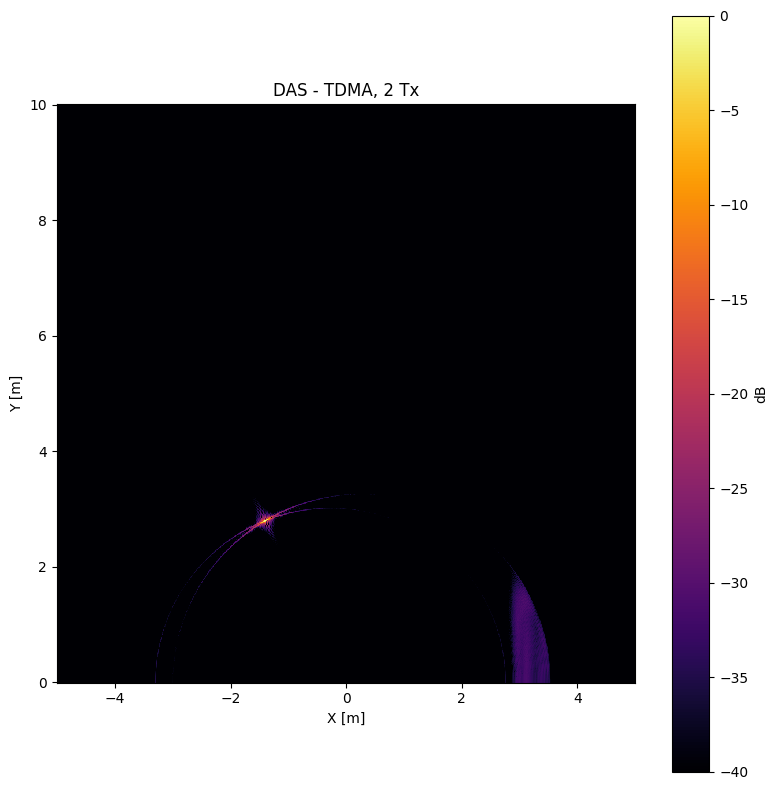

Running vectorized DAS on TDMA data (1 Tx)...
  Done in 1.5 s


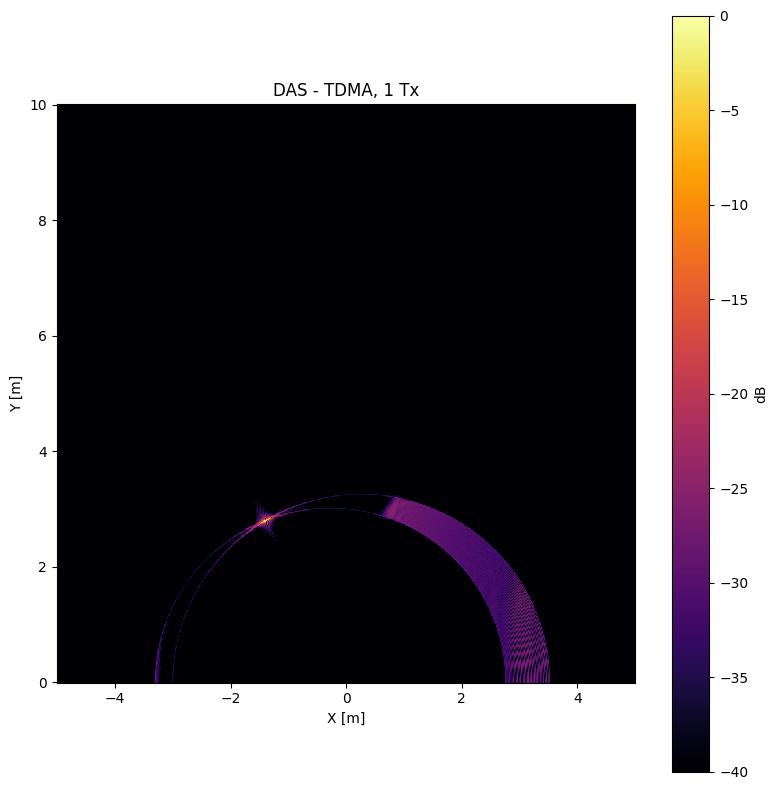

Running vectorized DAS on CDMA data...
  Done in 2.8 s


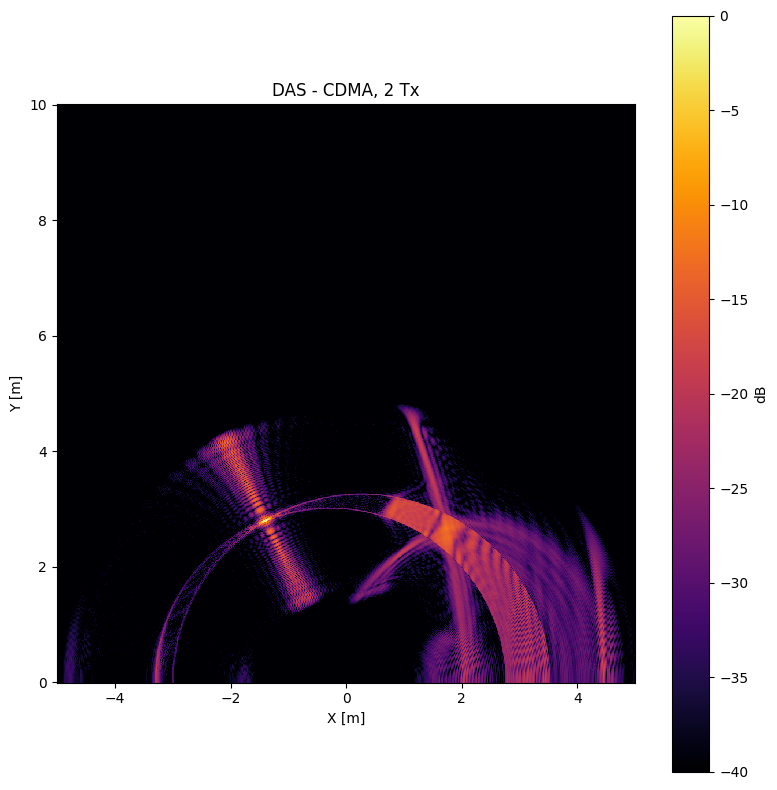

In [42]:
import time

# === Experiment 1: Full TDMA (2 Tx) ===
print("Running vectorized DAS on full TDMA data (2 Tx)...")
t0 = time.time()
image_tdma_2tx = vectorized_das(tdma_compressed, grid_x, grid_y, tx_pos, rx_pos, fs, c)
print(f"  Done in {time.time() - t0:.1f} s")
plot_das_image(image_tdma_2tx, grid_x, grid_y, title="DAS - TDMA, 2 Tx")

# === Experiment 2: Single Tx TDMA (Tx 0 only) ===
print("Running vectorized DAS on TDMA data (1 Tx)...")
t0 = time.time()
image_tdma_1tx = vectorized_das(tdma_compressed[:, :, 0:1], grid_x, grid_y,
                                 tx_pos[0:1], rx_pos, fs, c)
print(f"  Done in {time.time() - t0:.1f} s")
plot_das_image(image_tdma_1tx, grid_x, grid_y, title="DAS - TDMA, 1 Tx")
# Using only 1 Tx halves the virtual array, reducing the effective aperture and
# degrading the lateral resolution. The mainlobe widens in the x-direction.

# === Experiment 3: CDMA ===
# In CDMA, both waveforms are transmitted simultaneously. We pulse-compress the
# same cdma_data with each replica separately, then sum the DAS results.
print("Running vectorized DAS on CDMA data...")
cdma_compressed_up = np.stack(
    [pulse_compression(cdma_data[:, rx], s_tx_up) for rx in range(Nrx)], axis=1
)
cdma_compressed_down = np.stack(
    [pulse_compression(cdma_data[:, rx], s_tx_down) for rx in range(Nrx)], axis=1
)

t0 = time.time()
image_cdma_up = vectorized_das(cdma_compressed_up, grid_x, grid_y,
                                tx_pos[0:1], rx_pos, fs, c)
image_cdma_down = vectorized_das(cdma_compressed_down, grid_x, grid_y,
                                  tx_pos[1:2], rx_pos, fs, c)
image_cdma = image_cdma_up + image_cdma_down
print(f"  Done in {time.time() - t0:.1f} s")
plot_das_image(image_cdma, grid_x, grid_y, title="DAS - CDMA, 2 Tx")
# CDMA may show artifacts/pollution due to imperfect orthogonality of the upchirp
# and downchirp for finite-length sequences. Cross-talk between the two waveforms
# creates ghost reflections or raised sidelobe levels compared to TDMA.

Reflector found at: X = -1.400 m, Y = 2.800 m

=== Measured vs Theoretical Resolution (2-Tx TDMA) ===
Axial (Y):   measured FWHM = 2.00 cm,  theoretical δy = c/(2B) = 1.70 cm
Lateral (X): measured FWHM = 4.00 cm,  theoretical δx = R·λ/L_va = 25.40 cm


C:\Users\theod\AppData\Local\Temp\ipykernel_51776\1316883840.py:42: RuntimeWarning: divide by zero encountered in log10
  axes[0].plot(grid_y, 20 * np.log10(mag[:, peak_ix] / mag.max()))


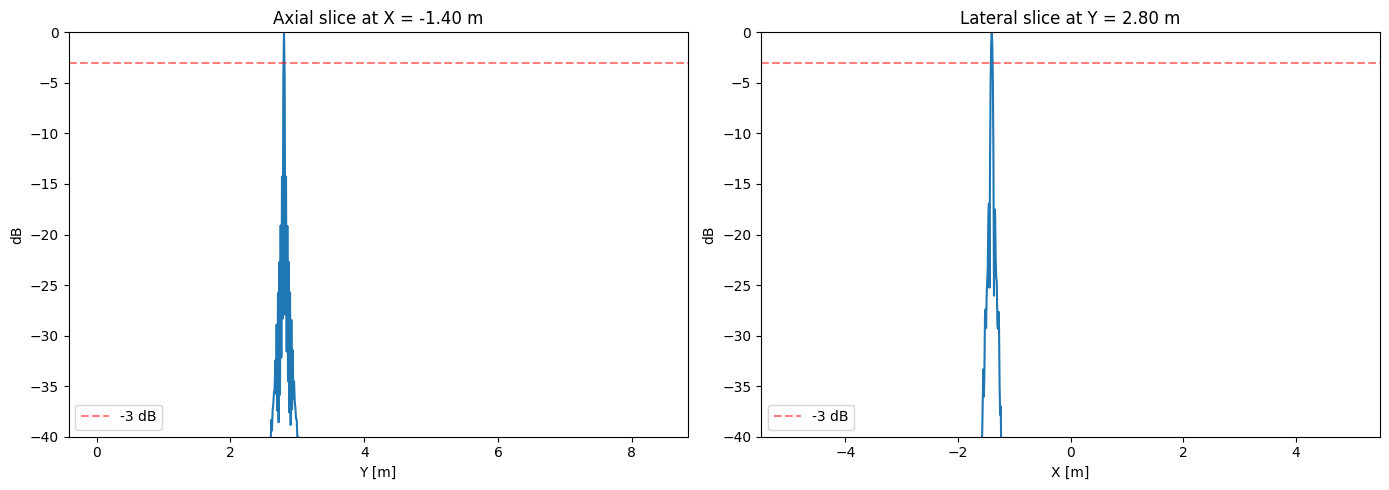

In [43]:
# === Resolution analysis on the full TDMA 2-Tx image ===
mag = np.abs(image_tdma_2tx)

# Find peak (reflector location)
peak_iy, peak_ix = np.unravel_index(np.argmax(mag), mag.shape)
x_peak = grid_x[peak_ix]
y_peak = grid_y[peak_iy]
print(f"Reflector found at: X = {x_peak:.3f} m, Y = {y_peak:.3f} m")

# --- Axial resolution (Y slice through peak) ---
axial_slice = mag[:, peak_ix] ** 2  # magnitude-squared
half_ax = axial_slice[peak_iy] / 2

# Find FWHM along Y
left_a = peak_iy
while left_a > 0 and axial_slice[left_a] >= half_ax:
    left_a -= 1
right_a = peak_iy
while right_a < len(axial_slice) - 1 and axial_slice[right_a] >= half_ax:
    right_a += 1
fwhm_axial = (right_a - left_a) * dy

# --- Lateral resolution (X slice through peak) ---
lateral_slice = mag[peak_iy, :] ** 2  # magnitude-squared
half_lat = lateral_slice[peak_ix] / 2

left_l = peak_ix
while left_l > 0 and lateral_slice[left_l] >= half_lat:
    left_l -= 1
right_l = peak_ix
while right_l < len(lateral_slice) - 1 and lateral_slice[right_l] >= half_lat:
    right_l += 1
fwhm_lateral = (right_l - left_l) * dx

print(f"\n=== Measured vs Theoretical Resolution (2-Tx TDMA) ===")
print(f"Axial (Y):   measured FWHM = {fwhm_axial*100:.2f} cm,  theoretical δy = c/(2B) = {delta_y*100:.2f} cm")
print(f"Lateral (X): measured FWHM = {fwhm_lateral*100:.2f} cm,  theoretical δx = R·λ/L_va = {delta_x*100:.2f} cm")

# --- Plot slices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(grid_y, 20 * np.log10(mag[:, peak_ix] / mag.max()))
axes[0].set_xlabel("Y [m]")
axes[0].set_ylabel("dB")
axes[0].set_title(f"Axial slice at X = {x_peak:.2f} m")
axes[0].set_ylim([-40, 0])
axes[0].axhline(-3, color="r", linestyle="--", alpha=0.5, label="-3 dB")
axes[0].legend()

axes[1].plot(grid_x, 20 * np.log10(mag[peak_iy, :] / mag.max()))
axes[1].set_xlabel("X [m]")
axes[1].set_ylabel("dB")
axes[1].set_title(f"Lateral slice at Y = {y_peak:.2f} m")
axes[1].set_ylim([-40, 0])
axes[1].axhline(-3, color="r", linestyle="--", alpha=0.5, label="-3 dB")
axes[1].legend()

plt.tight_layout()
plt.show()

### Part 4: Tapering Hamming Apodization

tdma_compressed_tapered shape: (10000, 32, 2)
Running tapered DAS (Hamming on Rx + tapered replica)...
  Done in 3.1 s


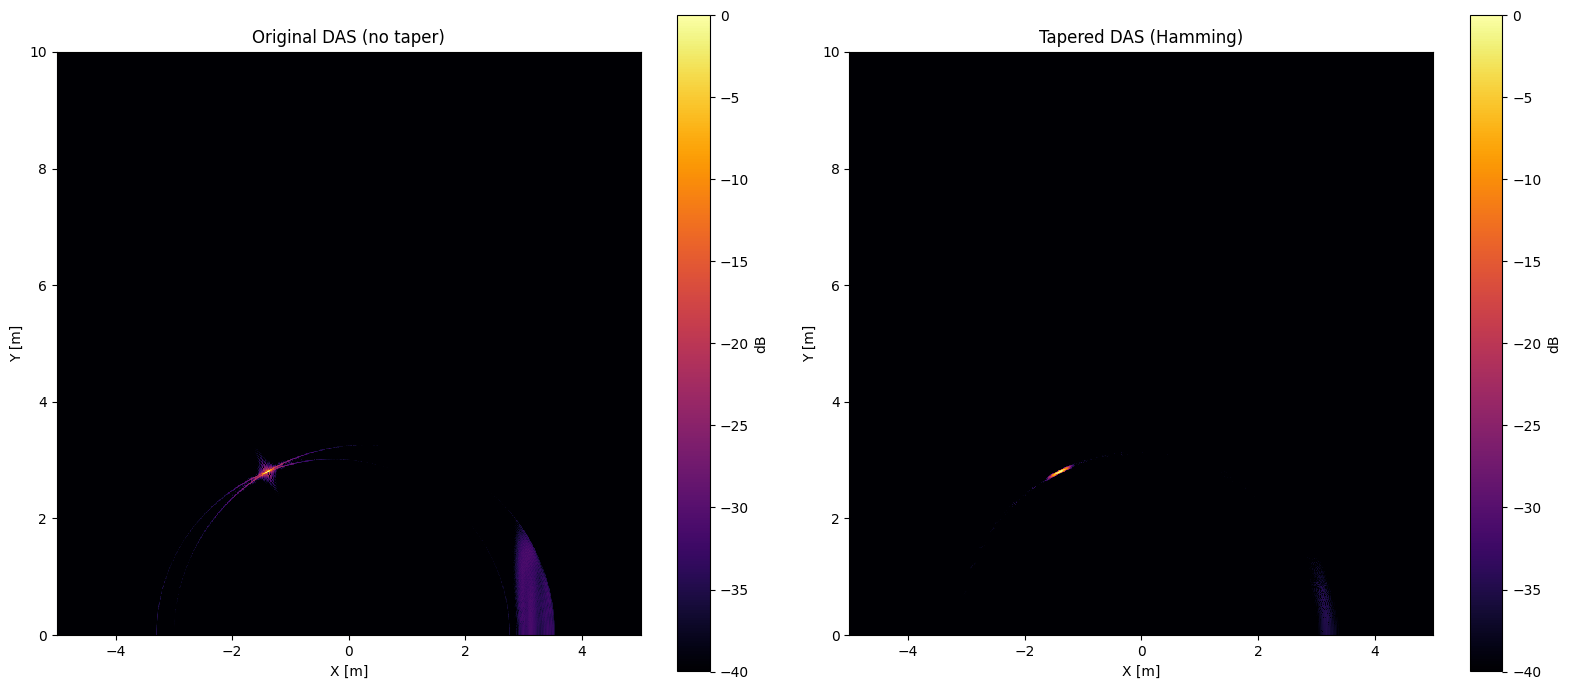


=== Quantitative Comparison ===
  [Original (no taper)]
    Axial FWHM:  2.00 cm
    Lateral FWHM: 4.00 cm
    Peak Sidelobe Level (lateral): -18.0 dB
  [Tapered (Hamming)]
    Axial FWHM:  4.00 cm
    Lateral FWHM: 6.00 cm
    Peak Sidelobe Level (lateral): -32.7 dB

--- Summary ---
Tapering reduces sidelobes by 14.7 dB (-18.0 → -32.7 dB)
but widens the mainlobe: axial 2.00 → 4.00 cm, lateral 4.00 → 6.00 cm.
This is the classic taper trade-off: lower sidelobes at the cost of wider mainlobe (reduced resolution).


In [44]:
# --- Generate Hamming weights ---
w_rx = np.hamming(Nrx)           # Spatial taper for receivers
w_tx = np.hamming(len(s_tx_up))  # Temporal taper for the LFM replica

# --- Tapered pulse compression ---
s_tx_up_tapered = s_tx_up * w_tx  # Apply temporal window to replica

tdma_compressed_tapered = np.stack(
    [
        np.stack(
            [pulse_compression(tdma_data[:, rx, tx], s_tx_up_tapered) for rx in range(Nrx)],
            axis=1,
        )
        for tx in range(Ntx)
    ],
    axis=2,
)
print(f"tdma_compressed_tapered shape: {tdma_compressed_tapered.shape}")


# --- Weighted DAS function ---
def vectorized_das_weighted(data, grid_x, grid_y, tx_positions, rx_positions, fs, c, rx_weights=None):
    """Vectorized DAS with optional per-receiver spatial weights."""
    if data.ndim == 2:
        data = data[:, :, np.newaxis]

    Nt_data, n_rx, n_tx = data.shape
    GX, GY = np.meshgrid(grid_x, grid_y)
    image = np.zeros((len(grid_y), len(grid_x)), dtype=complex)

    if rx_weights is None:
        rx_weights = np.ones(n_rx)

    for itx in range(n_tx):
        R_tx = np.sqrt((tx_positions[itx] - GX)**2 + GY**2)
        for irx in range(n_rx):
            R_rx = np.sqrt((rx_positions[irx] - GX)**2 + GY**2)
            idx_map = np.round((R_tx + R_rx) / c * fs).astype(int)
            valid = (idx_map >= 0) & (idx_map < Nt_data)
            idx_safe = np.clip(idx_map, 0, Nt_data - 1)
            pixel_values = data[idx_safe, irx, itx]
            pixel_values[~valid] = 0.0
            image += rx_weights[irx] * pixel_values

    return image


# --- Run tapered DAS ---
print("Running tapered DAS (Hamming on Rx + tapered replica)...")
t0 = time.time()
image_tapered = vectorized_das_weighted(
    tdma_compressed_tapered, grid_x, grid_y, tx_pos, rx_pos, fs, c, rx_weights=w_rx
)
print(f"  Done in {time.time() - t0:.1f} s")


# --- Side-by-side comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, img, title in zip(axes,
                           [image_tdma_2tx, image_tapered],
                           ["Original DAS (no taper)", "Tapered DAS (Hamming)"]):
    mag = np.abs(img)
    mag[mag == 0] = np.finfo(float).eps
    img_db = 20 * np.log10(mag / mag.max())
    im = ax.pcolormesh(grid_x, grid_y, img_db, shading="auto",
                       cmap="inferno", vmin=-40, vmax=0)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, label="dB")

plt.tight_layout()
plt.show()


# --- Quantitative analysis: FWHM and PSL for both images ---
def measure_fwhm_and_psl(image, grid_x, grid_y, dx, dy, label=""):
    """Measure FWHM (axial & lateral) and Peak Sidelobe Level for the strongest reflector."""
    mag = np.abs(image)
    peak_iy, peak_ix = np.unravel_index(np.argmax(mag), mag.shape)

    # --- Axial FWHM (Y slice) ---
    axial = mag[:, peak_ix] ** 2
    half_a = axial[peak_iy] / 2
    la = peak_iy
    while la > 0 and axial[la] >= half_a:
        la -= 1
    ra = peak_iy
    while ra < len(axial) - 1 and axial[ra] >= half_a:
        ra += 1
    fwhm_ax = (ra - la) * dy

    # --- Lateral FWHM (X slice) ---
    lateral = mag[peak_iy, :] ** 2
    half_l = lateral[peak_ix] / 2
    ll = peak_ix
    while ll > 0 and lateral[ll] >= half_l:
        ll -= 1
    rl = peak_ix
    while rl < len(lateral) - 1 and lateral[rl] >= half_l:
        rl += 1
    fwhm_lat = (rl - ll) * dx

    # --- Peak Sidelobe Level (lateral slice, dB relative to mainlobe) ---
    lat_db = 20 * np.log10(mag[peak_iy, :] / mag[peak_iy, :].max() + np.finfo(float).eps)
    # Null out mainlobe region (+/- some samples around peak)
    mainlobe_width = max(rl - ll, 5)
    sidelobe_region = lat_db.copy()
    sl_left = max(0, peak_ix - mainlobe_width)
    sl_right = min(len(lat_db), peak_ix + mainlobe_width + 1)
    sidelobe_region[sl_left:sl_right] = -np.inf
    psl = np.max(sidelobe_region)

    print(f"  [{label}]")
    print(f"    Axial FWHM:  {fwhm_ax*100:.2f} cm")
    print(f"    Lateral FWHM: {fwhm_lat*100:.2f} cm")
    print(f"    Peak Sidelobe Level (lateral): {psl:.1f} dB")
    return fwhm_ax, fwhm_lat, psl


print("\n=== Quantitative Comparison ===")
fwhm_ax_orig, fwhm_lat_orig, psl_orig = measure_fwhm_and_psl(
    image_tdma_2tx, grid_x, grid_y, dx, dy, label="Original (no taper)")
fwhm_ax_tap, fwhm_lat_tap, psl_tap = measure_fwhm_and_psl(
    image_tapered, grid_x, grid_y, dx, dy, label="Tapered (Hamming)")

print(f"\n--- Summary ---")
print(f"Tapering reduces sidelobes by {psl_orig - psl_tap:.1f} dB ({psl_orig:.1f} → {psl_tap:.1f} dB)")
print(f"but widens the mainlobe: axial {fwhm_ax_orig*100:.2f} → {fwhm_ax_tap*100:.2f} cm, "
      f"lateral {fwhm_lat_orig*100:.2f} → {fwhm_lat_tap*100:.2f} cm.")
print("This is the classic taper trade-off: lower sidelobes at the cost of wider mainlobe (reduced resolution).")

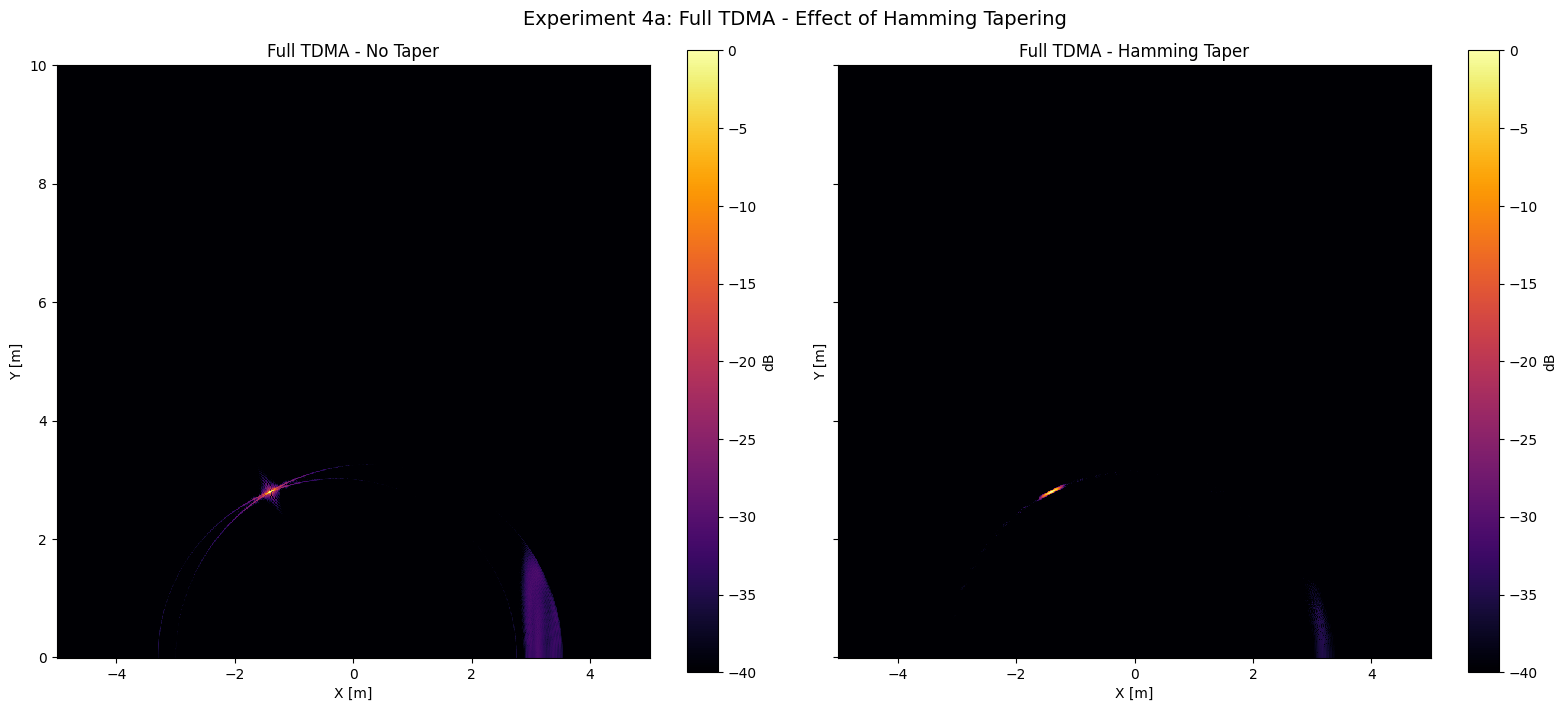

In [46]:

# =====================================================================
# Experiment 4a: Full TDMA (2 Tx) with Hamming tapering vs original
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
for ax, img, title in zip(axes,
                           [image_tdma_2tx, image_tapered],
                           ["Full TDMA - No Taper", "Full TDMA - Hamming Taper"]):
    m = np.abs(img)
    m[m == 0] = np.finfo(float).eps
    db = 20 * np.log10(m / m.max())
    im = ax.pcolormesh(grid_x, grid_y, db, shading="auto", cmap="inferno", vmin=-40, vmax=0)
    ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]"); ax.set_title(title); ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, label="dB")
plt.suptitle("Experiment 4a: Full TDMA - Effect of Hamming Tapering", fontsize=14)
plt.tight_layout()
plt.show()


Hamming tapering suppresses sidelobes around the reflectors, making the image cleaner. However, the mainlobe (PSF) widens in both axial and lateral directions, meaning we trade resolution for lower sidelobe artifacts. The reflector peaks are more distinct from the background.

Running tapered DAS on TDMA data (1 Tx)...
  Done in 1.9 s


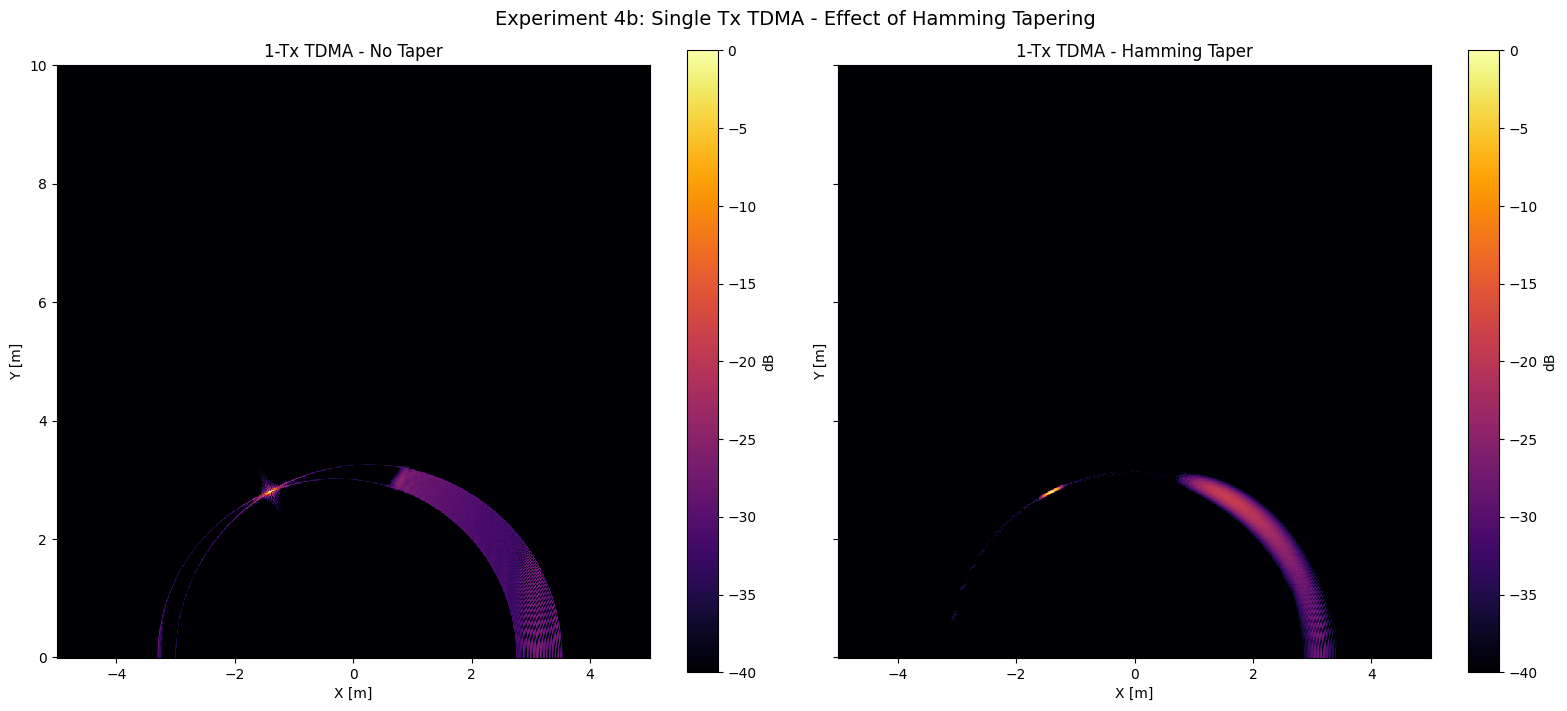

In [47]:

# =====================================================================
# Experiment 4b: Single Tx TDMA with Hamming tapering vs original 1-Tx
# =====================================================================
print("Running tapered DAS on TDMA data (1 Tx)...")
t0 = time.time()
image_1tx_tapered = vectorized_das_weighted(
    tdma_compressed_tapered[:, :, 0:1], grid_x, grid_y,
    tx_pos[0:1], rx_pos, fs, c, rx_weights=w_rx
)
print(f"  Done in {time.time() - t0:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
for ax, img, title in zip(axes,
                           [image_tdma_1tx, image_1tx_tapered],
                           ["1-Tx TDMA - No Taper", "1-Tx TDMA - Hamming Taper"]):
    m = np.abs(img)
    m[m == 0] = np.finfo(float).eps
    db = 20 * np.log10(m / m.max())
    im = ax.pcolormesh(grid_x, grid_y, db, shading="auto", cmap="inferno", vmin=-40, vmax=0)
    ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]"); ax.set_title(title); ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, label="dB")
plt.suptitle("Experiment 4b: Single Tx TDMA - Effect of Hamming Tapering", fontsize=14)
plt.tight_layout()
plt.show()


With only 1 Tx, the virtual array is half the length, so the lateral resolution is fundamentally degraded (wider mainlobe). Tapering reduces sidelobes somewhat, but it does **not** solve the underlying problem: the aperture is simply too small. The poor lateral resolution is a consequence of the reduced virtual aperture, not of sidelobes. Tapering only helps with sidelobe suppression, not aperture size.